In [1]:
import subprocess
subprocess.run(['pip', 'install', 'tensorflow', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn'], check=True)
print("✅ All packages ready!")

✅ All packages ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow version: {tf.__version__}")
print("✅ All imports successful!")

✅ TensorFlow version: 2.20.0
✅ All imports successful!


In [3]:
train_df = pd.read_csv('../dataset/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('../dataset/UNSW_NB15_testing-set.csv')

In [4]:
print(f"Training set : {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"Testing  set : {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")

print("\n--- Label distribution (0=Normal, 1=Attack) ---")
print(train_df['label'].value_counts())

Training set : 82,332 rows × 45 columns
Testing  set : 175,341 rows × 45 columns

--- Label distribution (0=Normal, 1=Attack) ---
label
1    45332
0    37000
Name: count, dtype: int64


In [5]:
DROP_COLS = ['id', 'attack_cat']
CAT_COLS  = ['proto', 'service', 'state']

def preprocess(df, encoders=None, fit=True):
    df = df.drop(columns=DROP_COLS, errors='ignore').copy()
    y  = df['label'].values
    df = df.drop(columns=['label'])

    if encoders is None:
        encoders = {}

    for col in CAT_COLS:
        if col in df.columns:
            if fit:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                encoders[col] = le
            else:
                le = encoders[col]
                df[col] = df[col].astype(str).apply(
                    lambda x: le.transform([x])[0] if x in le.classes_ else 0
                )
    return df.values, y, encoders

X_train_raw, y_train, encoders = preprocess(train_df, fit=True)
X_test_raw,  y_test,  _        = preprocess(test_df, encoders=encoders, fit=False)

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_test  shape: {X_test_raw.shape}")
print("✅ Preprocessing done!")

X_train shape: (82332, 42)
X_test  shape: (175341, 42)
✅ Preprocessing done!


In [6]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

X_train = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

n_features = X_train.shape[2]
print(f"Final shapes  →  Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Number of features: {n_features}")
print("✅ Scaling & reshaping done!")

Final shapes  →  Train: (82332, 1, 42)  |  Test: (175341, 1, 42)
Number of features: 42
✅ Scaling & reshaping done!


In [7]:
model = Sequential([
    Input(shape=(1, n_features)),
    GRU(32, return_sequences=True),    
    Dropout(0.2),                      
    GRU(64, return_sequences=False),   
    Dropout(0.2),
    Dense(128, activation='relu'),     
    Dropout(0.2),
    Dense(1, activation='sigmoid')     
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 32)          │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,561 (135.00 KB)

 Trainable params: 34,561 (135.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("🚀 GRU Training started...")

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ GRU Training complete!")

🚀 GRU Training started...
Epoch 1/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8352 - loss: 0.3474 - val_accuracy: 0.6261 - val_loss: 0.7163
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8994 - loss: 0.2014 - val_accuracy: 0.6845 - val_loss: 0.6262
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9097 - loss: 0.1824 - val_accuracy: 0.7656 - val_loss: 0.5286
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9193 - loss: 0.1691 - val_accuracy: 0.7469 - val_loss: 0.5385
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9262 - loss: 0.1570 - val_accuracy: 0.8370 - val_loss: 0.3981
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9336 - loss: 0.1455 - val_accuracy: 0.8041 - val_loss: 0.4424
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9394 - loss: 0.1368 - val_accuracy: 0.8532 - val_loss: 0.3671
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9427 - loss

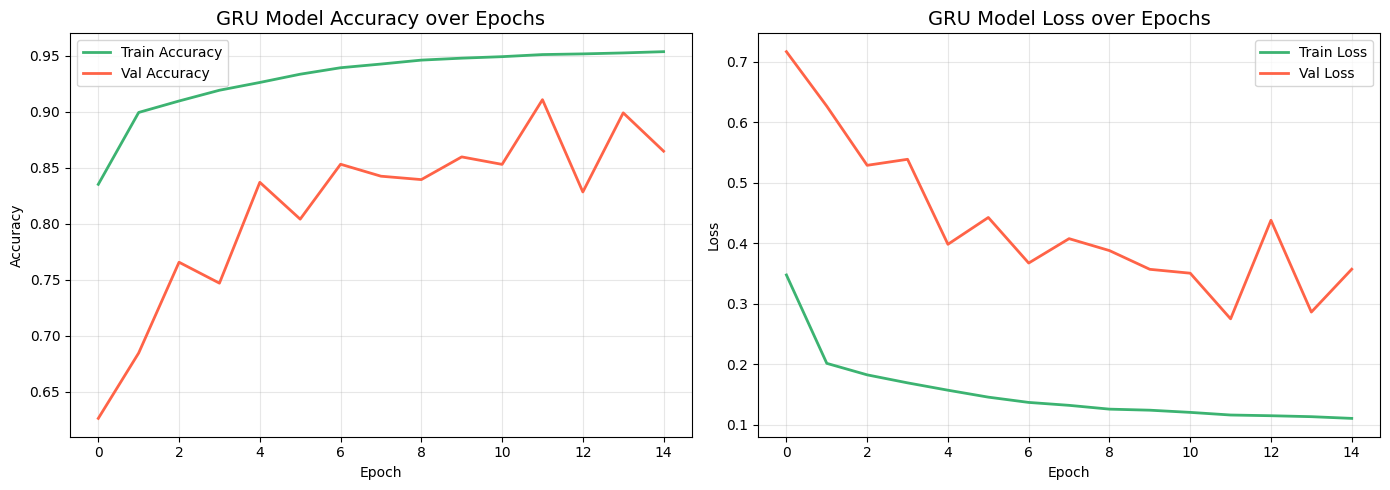

📊 Saved as gru_training_history.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='mediumseagreen', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato',        linewidth=2)
axes[0].set_title('GRU Model Accuracy over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='mediumseagreen', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato',        linewidth=2)
axes[1].set_title('GRU Model Loss over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gru_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved as gru_training_history.png")

In [10]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_pred)
print(f"{'='*45}")
print(f"  GRU Test Accuracy : {acc*100:.2f}%")
print(f"{'='*45}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Attack (1)']))

  GRU Test Accuracy : 88.28%

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.74      0.97      0.84     56000
  Attack (1)       0.98      0.84      0.91    119341

    accuracy                           0.88    175341
   macro avg       0.86      0.91      0.87    175341
weighted avg       0.91      0.88      0.89    175341



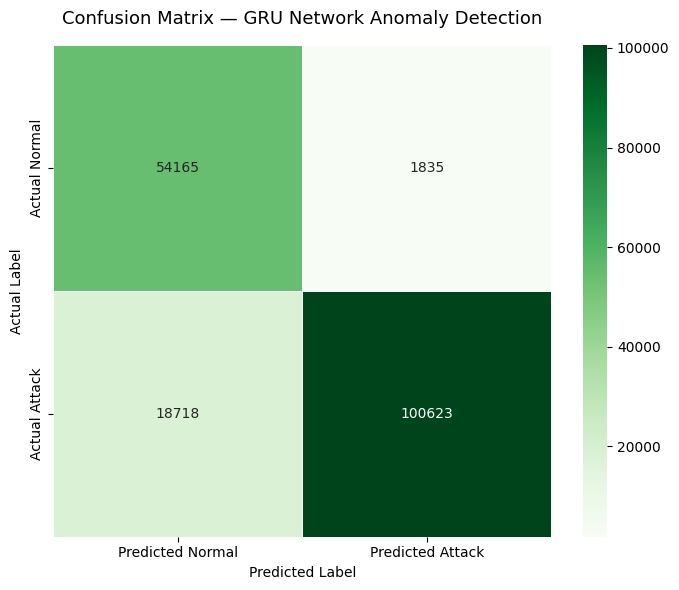


True  Negatives (Normal correctly identified): 54,165
False Positives (Normal flagged as Attack)   : 1,835
False Negatives (Attack missed)              : 18,718
True  Positives (Attack correctly detected)  : 100,623

📊 Saved as gru_confusion_matrix.png


In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicted Normal', 'Predicted Attack'],
    yticklabels=['Actual Normal', 'Actual Attack'],
    linewidths=0.5
)
plt.title('Confusion Matrix — GRU Network Anomaly Detection', fontsize=13, pad=15)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('gru_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (Normal correctly identified): {tn:,}")
print(f"False Positives (Normal flagged as Attack)   : {fp:,}")
print(f"False Negatives (Attack missed)              : {fn:,}")
print(f"True  Positives (Attack correctly detected)  : {tp:,}")
print("\n📊 Saved as gru_confusion_matrix.png")

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

gru_acc       = accuracy_score(y_test, y_pred)
gru_precision = precision_score(y_test, y_pred)
gru_recall    = recall_score(y_test, y_pred)
gru_f1        = f1_score(y_test, y_pred)

print("="*50)
print("       GRU Model — Final Scores")
print("="*50)
print(f"  Accuracy  : {gru_acc*100:.2f}%")
print(f"  Precision : {gru_precision*100:.2f}%")
print(f"  Recall    : {gru_recall*100:.2f}%")
print(f"  F1-Score  : {gru_f1*100:.2f}%")
print("="*50)
print("\n📌 Paper's reported score on UNSW_NB15:")
print("  Accuracy  : 95.55%  (DeepCLG = CNN+LSTM+GRU combined)")
print("  Your standalone GRU result above is a component of that.")

       GRU Model — Final Scores
  Accuracy  : 88.28%
  Precision : 98.21%
  Recall    : 84.32%
  F1-Score  : 90.73%

📌 Paper's reported score on UNSW_NB15:
  Accuracy  : 95.55%  (DeepCLG = CNN+LSTM+GRU combined)
  Your standalone GRU result above is a component of that.
